In [271]:
import numpy as np
import matplotlib.pyplot as plt
import os
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cdo import Cdo
import pandas as pd

In [238]:
cdo = Cdo()

### Retrieving data filepaths 

In [239]:
# Get current working directory
script_dir = os.getcwd()

data_pi = script_dir + '/pi_control_smhi'
data_2K = script_dir + '/gwl2p0_knmi'
data_4K = script_dir + '/gwl4p0_dmi'

#nc_files = [f for f in os.listdir(data_4K) if f.endswith('.nc')]
#print(nc_files)

def files(data_scenario):
    file_tas = [f for f in os.listdir(data_scenario) if f.startswith('tas')][0]
    file_prsn = [f for f in os.listdir(data_scenario) if f.startswith('prsn')][0]
    file_pr = [f for f in os.listdir(data_scenario) if f.startswith('pr_')][0]
    return file_tas, file_prsn, file_pr
    
def sliced_filepath(data_scenario):
    sliced_file_tas = [f for f in os.listdir(data_scenario) if f.startswith('sliced_tas')][0]
    sliced_file_prsn = [f for f in os.listdir(data_scenario) if f.startswith('sliced_prsn')][0]
    sliced_file_pr = [f for f in os.listdir(data_scenario) if f.startswith('sliced_pr_')][0]
    return data_scenario + '/' + sliced_file_tas, data_scenario + '/' + sliced_file_prsn, data_scenario + '/' + sliced_file_pr

def sliced_detrended_files(data_scenario):
    sliced_file_tas = [f for f in os.listdir(data_scenario) if f.startswith('sliced_detrended_tas')][0]
    sliced_file_prsn = [f for f in os.listdir(data_scenario) if f.startswith('sliced_detrended_prsn')][0]
    sliced_file_pr = [f for f in os.listdir(data_scenario) if f.startswith('sliced_detrended_pr_')][0]
    sliced_file_snfr = [f for f in os.listdir(data_scenario) if f.startswith('sliced_detrended_s')][0]
    return sliced_file_tas, sliced_file_prsn, sliced_file_pr, sliced_file_snfr

def sliced_detrended_filepath(data_scenario):
    sliced_file_tas = [f for f in os.listdir(data_scenario) if f.startswith('sliced_detrended_tas')][0]
    sliced_file_prsn = [f for f in os.listdir(data_scenario) if f.startswith('sliced_detrended_prsn')][0]
    sliced_file_pr = [f for f in os.listdir(data_scenario) if f.startswith('sliced_detrended_pr_')][0]
    sliced_file_snfr = [f for f in os.listdir(data_scenario) if f.startswith('sliced_detrended_s')][0]
    return data_scenario + '/' + sliced_file_tas, data_scenario + '/' + sliced_file_prsn, data_scenario + '/' + sliced_file_pr, data_scenario + '/' + sliced_file_snfr


def yearly_filepath(data_scenario):
    yearly_file_tas = [f for f in os.listdir(data_scenario) if f.startswith('yearmean_sliced_detrended_tas')][0]
    yearly_file_prsn = [f for f in os.listdir(data_scenario) if f.startswith('yearmean_sliced_detrended_prsn')][0]
    yearly_file_pr = [f for f in os.listdir(data_scenario) if f.startswith('yearmean_sliced_detrended_pr_')][0]
    yearly_file_snfr = [f for f in os.listdir(data_scenario) if f.startswith('yearmean_sliced_detrended_sn')][0]
    return data_scenario + '/' + yearly_file_tas, data_scenario + '/' + yearly_file_prsn, data_scenario + '/' + yearly_file_pr, data_scenario + '/' + yearly_file_snfr
    
def filepath(data_scenario):
    filepaths = []
    for file in files(data_scenario):
        filepaths.append(data_scenario + '/'+ file)
    return filepaths

# All the filepaths or the original datafiles
file_tas_pi, file_prsn_pi, file_pr_pi = filepath(data_pi)
file_tas_2K, file_prsn_2K, file_pr_2K = filepath(data_2K)
file_tas_4K, file_prsn_4K, file_pr_4K = filepath(data_4K)

# Data Processing

### Slicing data

In [240]:
# ## This part of the code should only be run once, to create the correct files

# # checking the lengths of the data and select shortest as length for all files
# data_len = min(int(cdo.ntime(input = file_tas_pi)[0]), 
#                int(cdo.ntime(input = file_tas_2K)[0]), 
#                int(cdo.ntime(input = file_tas_4K)[0]))

# def sliced(data_scenario, data_len):
#     sliced_files = []
#     for file in files(data_scenario):
#         sliced_file = 'sliced_'+file
#         sliced_files.append(data_scenario + '/' + sliced_file)
#         cdo.seltimestep(f'1/{data_len}', input = data_scenario + '/' + file, output = data_scenario + '/' + sliced_file)
#     return sliced_files

# file_tas_pi_sliced, file_prsn_pi_sliced, file_pr_pi_sliced = sliced(data_pi, data_len)
# file_tas_2K_sliced, file_prsn_2K_sliced, file_pr_2K_sliced = sliced(data_2K, data_len)
# file_tas_4K_sliced, file_prsn_4K_sliced, file_pr_4K_sliced = sliced(data_4K, data_len) 

### Calculating snow fraction


In [297]:
## This part of the code should only be run once, to create the correct files

# Calculate the fraction between snow and precipitation and make values higher than 1.1 0, to take out instances of zero precipitation
def snow_fraction(data_scenario):
    file_tas_sliced, file_prsn_sliced, file_pr_sliced = sliced_filepath(data_scenario)    
    cdo.setrtoc("-0.01,0,0", input=cdo.setvrange('-0.01,1.001', input=cdo.div(input = f'{file_prsn_sliced} {file_pr_sliced}')), output = f'{data_scenario}/snow_fraction.nc')
    return f'{data_scenario}/snow_fraction.nc'

file_snow_fraction_pi = snow_fraction(data_pi)
file_snow_fraction_2K = snow_fraction(data_2K)
file_snow_fraction_4K = snow_fraction(data_4K)

### Detrending data

In [298]:
# This part of the code should only be run once, to create the correct files

def detrend(data_scenario, data_len):
    sliced_files = sliced_filepath(data_scenario)
    sliced_detrended_files = []
    for i, file in enumerate(files(data_scenario)):
        sliced_detrended_file = 'sliced_detrended_'+file
        sliced_detrended_files.append(data_scenario + '/' + sliced_detrended_file)
        cdo.detrend(input = sliced_files[i], output = data_scenario + '/' + sliced_detrended_file)
    sliced_detrended_files.append('sliced_detrended_snowfraction.nc')
    cdo.detrend(input = f'{data_scenario}/snow_fraction.nc', output = data_scenario + '/' + 'sliced_detrended_snowfraction.nc')
    return sliced_detrended_files

file_tas_pi_sliced_detrended, file_prsn_pi_sliced_detrended, file_pr_pi_sliced_detrended, file_snfr_pi_sliced_detrended = detrend(data_pi, data_len)
file_tas_2K_sliced_detrended, file_prsn_2K_sliced_detrended, file_pr_2K_sliced_detrended, file_snfr_pi_sliced_detrended = detrend(data_2K, data_len)
file_tas_4K_sliced_detrended, file_prsn_4K_sliced_detrended, file_pr_4K_sliced_detrended, file_snfr_pi_sliced_detrended = detrend(data_4K, data_len) 

### Seisonal detrending monthly data

In [299]:
def seisonal_detrend(data_array):
    new_data = []
    for month in range(1,13):
        month_data = data_array.sel(time=data_array['time'].dt.month ==month)
        month_mean = month_data.mean(dim = 'time')
        new_data.append(month_data-month_mean)
    return xr.concat(new_data, dim = 'time')

### Calculating yearly means

In [300]:
def yearmean(data_scenario):
    yearmean_files = []
    for file in sliced_detrended_files(data_scenario):
        yearmean_file = 'yearmean_'+file
        yearmean_files.append(data_scenario + '/' + yearmean_file)
        cdo.yearmean(input = data_scenario + '/' + file, output= data_scenario + '/' + yearmean_file)
    return yearmean_files

file_yrmean_tas_pi, file_yrmean_prsn_pi, file_yrmean_pr_pi, file_yrmean_snfr_pi = yearmean(data_pi)
file_yrmean_tas_2K, file_yrmean_prsn_2K, file_yrmean_pr_2K, file_yrmean_snfr_2K = yearmean(data_2K)
file_yrmean_tas_4K, file_yrmean_prsn_4K, file_yrmean_pr_4K, file_yrmean_snfr_4K = yearmean(data_4K)

In [301]:
def yearly_mean(data_array):
    new_data = []
    month_lengths = [31,28,31,30,31,30,31,31,30,31,30,31] # DOES THE MODEL CONSIDER GAP YEARS?
    for i, month in enumerate(range(1,13)):
        month_data = data_array.sel(time=data_array['time'].dt.month ==month)
        new_data.append(month_data * month_lengths[i])
    monthly_total = xr.concat(new_data, dim = 'time').mean
    

# Opening data

### Retrieving filenames of detrended, sliced data (yearly and monthly means)

In [302]:
file_tas_pi_sliced, file_prsn_pi_sliced, file_pr_pi_sliced = sliced_filepath(data_pi)
file_tas_2K_sliced, file_prsn_2K_sliced, file_pr_2K_sliced = sliced_filepath(data_2K)
file_tas_4K_sliced, file_prsn_4K_sliced, file_pr_4K_sliced = sliced_filepath(data_4K)
file_snfr_pi_sliced = data_pi + '/snow_fraction.nc'
file_snfr_2K_sliced = data_2K + '/snow_fraction.nc'
file_snfr_4K_sliced = data_4K + '/snow_fraction.nc'

file_yrmean_tas_pi, file_yrmean_prsn_pi, file_yrmean_pr_pi, file_yrmean_snfr_pi = yearly_filepath(data_pi)
file_yrmean_tas_2K, file_yrmean_prsn_2K, file_yrmean_pr_2K, file_yrmean_snfr_2K  = yearly_filepath(data_2K)
file_yrmean_tas_4K, file_yrmean_prsn_4K, file_yrmean_pr_4K, file_yrmean_snfr_4K  = yearly_filepath(data_4K)

file_tas_pi_sliced_detrended, file_prsn_pi_sliced_detrended, file_pr_pi_sliced_detrended, file_snfr_pi_sliced_detrended  = sliced_detrended_filepath(data_pi)
file_tas_2K_sliced_detrended, file_prsn_2K_sliced_detrended, file_pr_2K_sliced_detrended, file_snfr_2K_sliced_detrended  = sliced_detrended_filepath(data_2K)
file_tas_4K_sliced_detrended, file_prsn_4K_sliced_detrended, file_pr_4K_sliced_detrended, file_snfr_4K_sliced_detrended  = sliced_detrended_filepath(data_4K) 

### Opening sliced (not detrended) data

In [303]:
sliced_tas_pi = xr.open_dataset(file_tas_pi_sliced)
sliced_pr_pi = xr.open_dataset(file_pr_pi_sliced)
sliced_prsn_pi = xr.open_dataset(file_prsn_pi_sliced)
sliced_snfr_pi = xr.open_dataset(file_snfr_pi_sliced)

# Retrieving the time array to set it the same for all datasets
time_array = sliced_tas_pi.time.values

# # opeing + 2K
sliced_tas_2K = xr.open_dataset(file_tas_2K_sliced, decode_times = False).assign_coords(time=("time", time_array))
sliced_pr_2K = xr.open_dataset(file_pr_2K_sliced, decode_times = False).assign_coords(time=("time", time_array))
sliced_prsn_2K = xr.open_dataset(file_prsn_2K_sliced, decode_times = False).assign_coords(time=("time", time_array))
sliced_snfr_2K = xr.open_dataset(file_snfr_2K_sliced, decode_times = False).assign_coords(time=("time", time_array))

#opening + 4K
sliced_tas_4K = xr.open_dataset(file_tas_4K_sliced, decode_times = False).assign_coords(time=("time", time_array))
sliced_pr_4K = xr.open_dataset(file_pr_4K_sliced, decode_times = False).assign_coords(time=("time", time_array))
sliced_prsn_4K = xr.open_dataset(file_prsn_4K_sliced, decode_times = False).assign_coords(time=("time", time_array))
sliced_snfr_4K = xr.open_dataset(file_snfr_4K_sliced, decode_times = False).assign_coords(time=("time", time_array))



### Opening sliced, detrended data

In [304]:
#opening pre-industrial
tas_pi = seisonal_detrend(xr.open_dataset(file_tas_pi_sliced_detrended))
pr_pi = seisonal_detrend(xr.open_dataset(file_pr_pi_sliced_detrended))
prsn_pi = seisonal_detrend(xr.open_dataset(file_prsn_pi_sliced_detrended))
snfr_pi = seisonal_detrend(xr.open_dataset(file_snfr_pi_sliced_detrended))

tas_pi_yearly = xr.open_dataset(file_yrmean_tas_pi)
pr_pi_yearly = xr.open_dataset(file_yrmean_pr_pi)
prsn_pi_yearly = xr.open_dataset(file_yrmean_prsn_pi)
snfr_pi_yearly = xr.open_dataset(file_yrmean_snfr_pi)

# Retrieving the time array to set it the same for all datasets
time_array = tas_pi.time.values
yearly_time_array = tas_pi_yearly.time.values

# opeing + 2K
tas_2K = xr.open_dataset(file_tas_2K_sliced_detrended, decode_times = False).assign_coords(time=("time", time_array))
tas_2K = seisonal_detrend(tas_2K)
pr_2K = xr.open_dataset(file_pr_2K_sliced_detrended, decode_times = False).assign_coords(time=("time", time_array))
pr_2K = seisonal_detrend(pr_2K)
prsn_2K = xr.open_dataset(file_prsn_2K_sliced_detrended, decode_times = False).assign_coords(time=("time", time_array))
prsn_2K = seisonal_detrend(prsn_2K)
snfr_2K = xr.open_dataset(file_snfr_2K_sliced_detrended, decode_times = False).assign_coords(time=("time", time_array))
snfr_2K = seisonal_detrend(snfr_2K)

tas_2K_yearly = xr.open_dataset(file_yrmean_tas_2K, decode_times = False).assign_coords(time=("time", yearly_time_array))
pr_2K_yearly = xr.open_dataset(file_yrmean_pr_2K, decode_times = False).assign_coords(time=("time", yearly_time_array))
prsn_2K_yearly = xr.open_dataset(file_yrmean_prsn_2K, decode_times = False).assign_coords(time=("time", yearly_time_array))
snfr_2K_yearly = xr.open_dataset(file_yrmean_snfr_2K, decode_times = False).assign_coords(time=("time", yearly_time_array))


#opening + 4K
tas_4K = xr.open_dataset(file_tas_4K_sliced_detrended, decode_times = False).assign_coords(time=("time", time_array))
tas_4K = seisonal_detrend(tas_4K)
pr_4K = xr.open_dataset(file_pr_4K_sliced_detrended, decode_times = False).assign_coords(time=("time", time_array))
pr_4K = seisonal_detrend(pr_4K)
prsn_4K = xr.open_dataset(file_prsn_4K_sliced_detrended, decode_times = False).assign_coords(time=("time", time_array))
prsn_4K = seisonal_detrend(prsn_4K)
snfr_4K = xr.open_dataset(file_snfr_4K_sliced_detrended, decode_times = False).assign_coords(time=("time", time_array))
snfr_4K = seisonal_detrend(snfr_4K)


tas_4K_yearly = xr.open_dataset(file_yrmean_tas_4K, decode_times = False).assign_coords(time=("time", yearly_time_array))
pr_4K_yearly = xr.open_dataset(file_yrmean_pr_4K, decode_times = False).assign_coords(time=("time", yearly_time_array))
prsn_4K_yearly = xr.open_dataset(file_yrmean_prsn_4K, decode_times = False).assign_coords(time=("time", yearly_time_array))
snfr_4K_yearly = xr.open_dataset(file_yrmean_snfr_4K, decode_times = False).assign_coords(time=("time", yearly_time_array))


# Means

### Calculating means of Northern Hemisphere

In [305]:
# calculating means pi 
tas_pi_mean = tas_pi['tas'].mean(dim = ['lon', 'lat'])
tas_pi_yearly_mean = tas_pi_yearly.mean(dim = ['lon', 'lat'])

pr_pi_mean = pr_pi['pr'].mean(dim = ['lon', 'lat'])
pr_pi_yearly_mean = pr_pi_yearly.mean(dim = ['lon', 'lat'])

prsn_pi_mean = prsn_pi['prsn'].mean(dim = ['lon', 'lat'])
prsn_pi_yearly_mean = prsn_pi_yearly.mean(dim = ['lon', 'lat'])

snfr_pi_mean = snfr_pi['prsn'].mean(dim = ['lon', 'lat'])
snfr_pi_yearly_mean = snfr_pi_yearly.mean(dim = ['lon', 'lat'])

#calculating means +2K
tas_2K_mean = tas_2K['tas'].mean(dim = ['lon', 'lat'])
tas_2K_yearly_mean = tas_2K_yearly.mean(dim = ['lon', 'lat'])

pr_2K_mean = pr_2K['pr'].mean(dim = ['lon', 'lat'])
pr_2K_yearly_mean = pr_2K_yearly.mean(dim = ['lon', 'lat'])

prsn_2K_mean = prsn_2K['prsn'].mean(dim = ['lon', 'lat'])
prsn_2K_yearly_mean = prsn_2K_yearly.mean(dim = ['lon', 'lat'])

snfr_2K_mean = snfr_2K['prsn'].mean(dim = ['lon', 'lat'])
snfr_2K_yearly_mean = snfr_2K_yearly.mean(dim = ['lon', 'lat'])

# calculating means +4K
tas_4K_mean = tas_4K['tas'].mean(dim = ['lon', 'lat'])
tas_4K_yearly_mean = tas_4K_yearly.mean(dim = ['lon', 'lat'])

pr_4K_mean = pr_4K['pr'].mean(dim = ['lon', 'lat'])
pr_4K_yearly_mean = pr_4K_yearly.mean(dim = ['lon', 'lat'])

prsn_4K_mean = prsn_4K['prsn'].mean(dim = ['lon', 'lat'])
prsn_4K_yearly_mean = prsn_4K_yearly.mean(dim = ['lon', 'lat'])

snfr_4K_mean = prsn_4K['prsn'].mean(dim = ['lon', 'lat'])
snfr_4K_yearly_mean = prsn_4K_yearly.mean(dim = ['lon', 'lat'])




### Plotting the means of the Northern Hemisphere

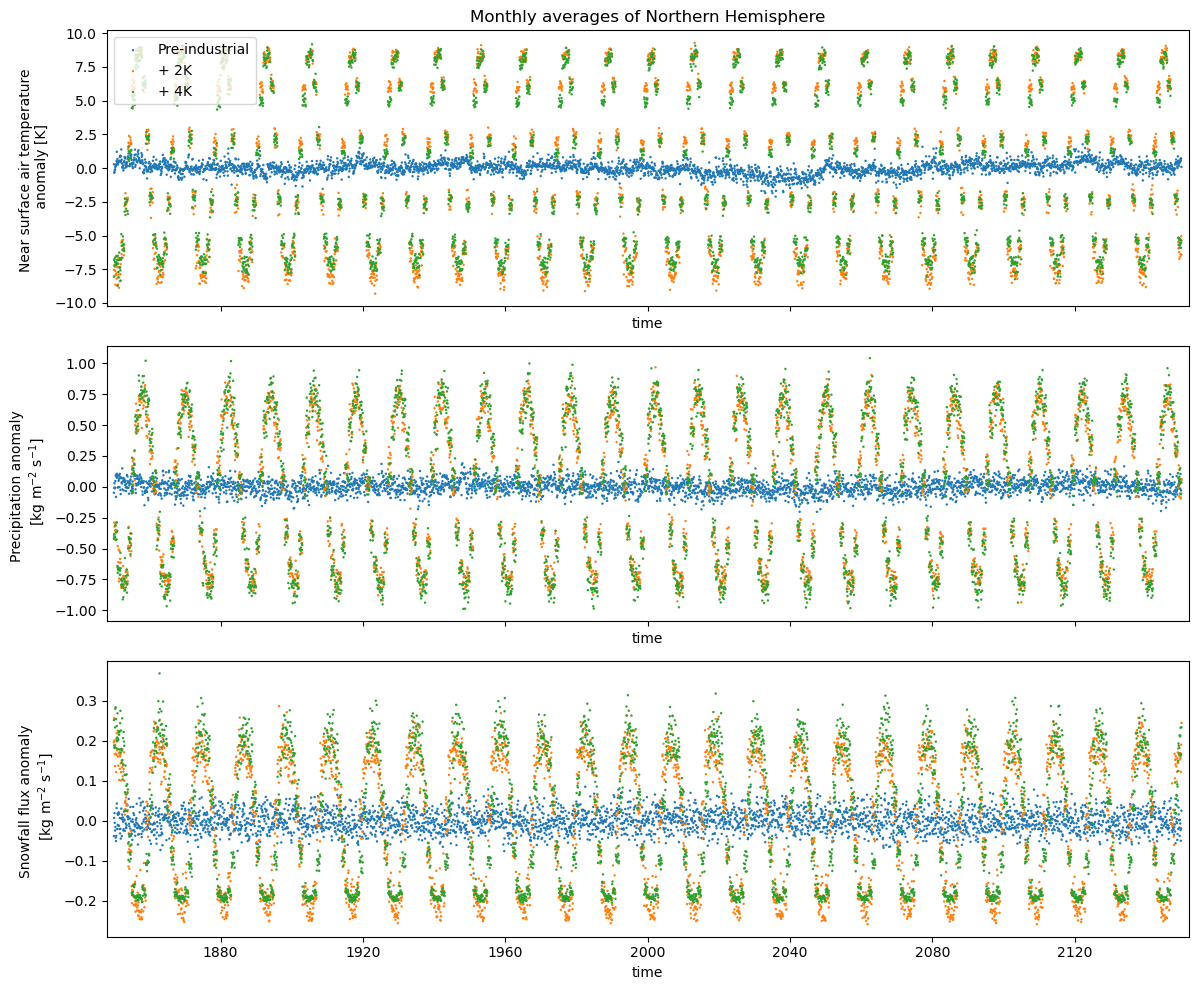

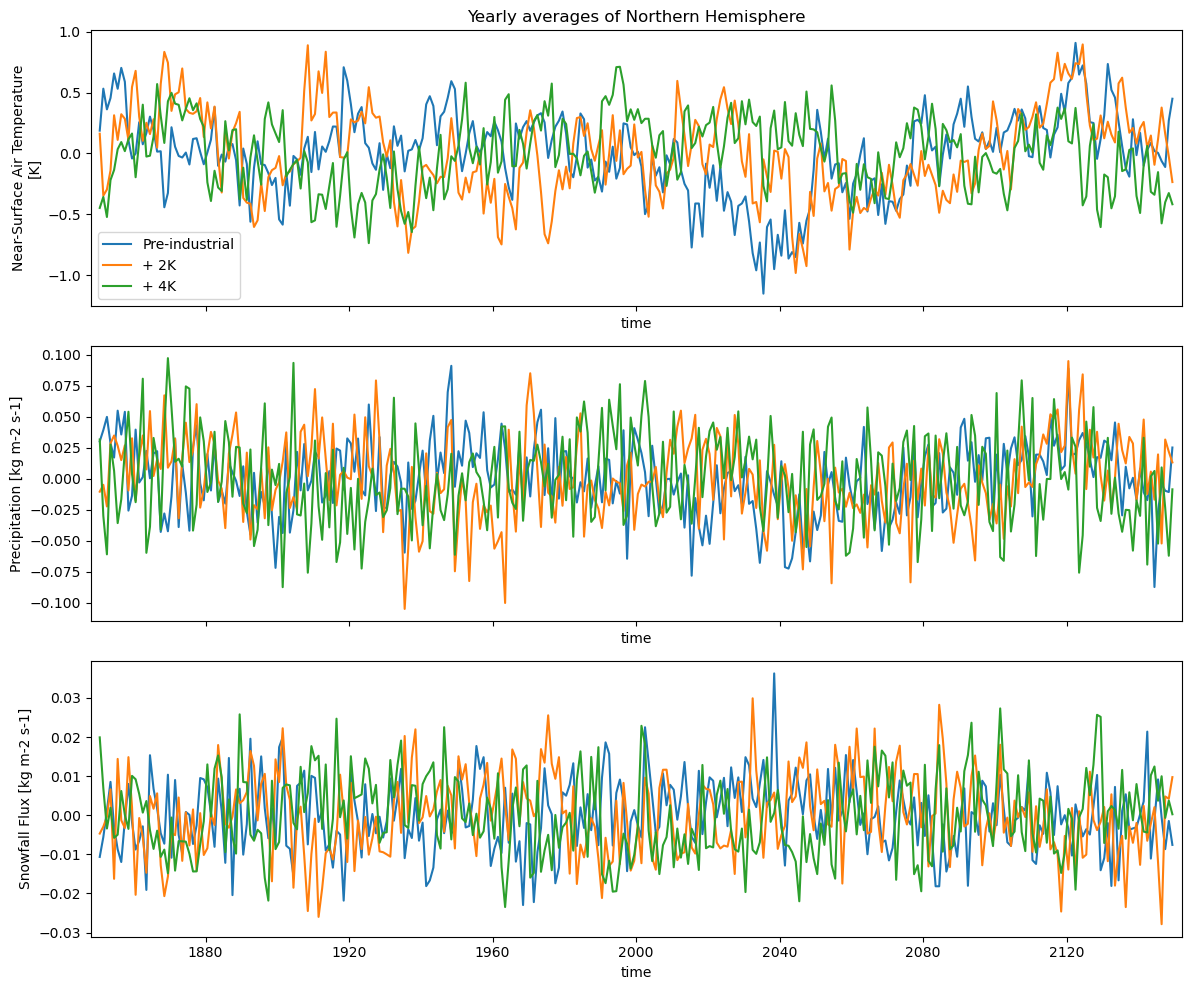

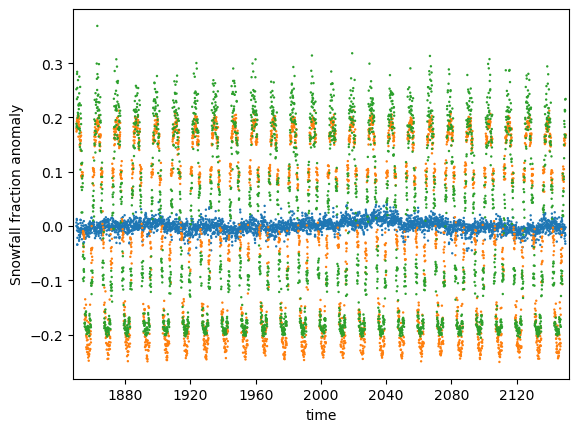

In [306]:
# fig, ax = plt.subplots(4,1, figsize = (12,12), sharex = True)
fig, ax = plt.subplots(3,1, figsize = (12,10), sharex = True)

tas_pi_mean.plot.scatter(x = 'time', ax = ax[0], s = 3, edgecolors = 'none', label = 'Pre-industrial')
tas_2K_mean.plot.scatter(x = 'time', ax = ax[0], s = 3, edgecolors = 'none', label = '+ 2K')
tas_4K_mean.plot.scatter(x = 'time', ax = ax[0], s = 3, edgecolors = 'none', label = '+ 4K')
ax[0].legend()
ax[0].set_title('Monthly averages of Northern Hemisphere')
ax[0].set_ylabel('Near surface air temperature \n anomaly [K]')

pr_pi_mean.plot.scatter(ax = ax[1], s = 3, edgecolors = 'none')
pr_2K_mean.plot.scatter(ax = ax[1], s = 3, edgecolors = 'none')
pr_4K_mean.plot.scatter(ax = ax[1], s = 3, edgecolors = 'none')
ax[1].set_ylabel('Precipitation anomaly \n [kg m$^{-2}$ s$^{-1}$]')

prsn_pi_mean.plot.scatter(ax = ax[2], s = 3, edgecolors = 'none')
prsn_2K_mean.plot.scatter(ax = ax[2], s = 3, edgecolors = 'none')
prsn_4K_mean.plot.scatter(ax = ax[2], s = 3, edgecolors = 'none')
ax[2].set_ylabel('Snowfall flux anomaly \n [kg m$^{-2}$ s$^{-1}$]')

# snfr_pi_mean.plot.scatter(ax = ax[3], s = 3, edgecolors = 'none')
# snfr_2K_mean.plot.scatter(ax = ax[3], s = 3, edgecolors = 'none')
# snfr_4K_mean.plot.scatter(ax = ax[3], s = 3, edgecolors = 'none')
# ax[3].set_ylabel('Snowfall fraction anomaly')
plt.xlim(pd.to_datetime('1848-01-01'), pd.to_datetime('2152-01-20'))

fig.tight_layout()
plt.savefig('Monthly_averages_NH.png')

plt.show()

# fig, ax = plt.subplots(4,1, figsize = (12,12), sharex = True)
fig, ax = plt.subplots(3,1, figsize = (12,10), sharex = True)
tas_pi_yearly_mean['tas'].plot(x = 'time', ax = ax[0], label = 'Pre-industrial')
tas_2K_yearly_mean['tas'].plot(x = 'time', ax = ax[0], label = '+ 2K')
tas_4K_yearly_mean['tas'].plot(x = 'time', ax = ax[0], label = '+ 4K')
ax[0].legend()
ax[0].set_title('Yearly averages of Northern Hemisphere')

pr_pi_yearly_mean['pr'].plot(x = 'time', ax = ax[1])
pr_2K_yearly_mean['pr'].plot(x = 'time', ax = ax[1])
pr_4K_yearly_mean['pr'].plot(x = 'time', ax = ax[1])

prsn_pi_yearly_mean['prsn'].plot(x = 'time', ax = ax[2])
prsn_2K_yearly_mean['prsn'].plot(x = 'time', ax = ax[2])
prsn_4K_yearly_mean['prsn'].plot(x = 'time', ax = ax[2])

# snfr_pi_yearly_mean['prsn'].plot(x = 'time', ax = ax[3])
# snfr_2K_yearly_mean['prsn'].plot(x = 'time', ax = ax[3])
# snfr_4K_yearly_mean['prsn'].plot(x = 'time', ax = ax[3])
plt.xlim(pd.to_datetime('1848-01-01'), pd.to_datetime('2152-01-20'))

fig.tight_layout()
plt.savefig('Yearly_averages_NH.png')
plt.show()

plt.figure()
snfr_pi_mean.plot.scatter(s = 3, edgecolors = 'none')
snfr_2K_mean.plot.scatter(s = 3, edgecolors = 'none')
snfr_4K_mean.plot.scatter(s = 3, edgecolors = 'none')
plt.ylabel('Snowfall fraction anomaly')
plt.xlim(pd.to_datetime('1848-01-01'), pd.to_datetime('2152-01-20'))
plt.savefig('Monthly_snfr_NH.png')




# Variability

### Calculating variability


In [307]:
variability_tas_pi = tas_pi_yearly['tas'].std(dim = 'time') 
variability_tas_pi = variability_tas_pi.sel(lat = slice(20,90))

variability_tas_2K = tas_2K_yearly['tas'].std(dim = 'time') 
variability_tas_2K = variability_tas_2K.sel(lat = slice(20,90))

variability_tas_4K = tas_4K_yearly['tas'].std(dim = 'time') 
variability_tas_4K = variability_tas_4K.sel(lat = slice(20,90))

variability_pr_pi = pr_pi_yearly['pr'].std(dim = 'time') 
variability_pr_pi = variability_pr_pi.sel(lat = slice(20,90))

variability_pr_2K = pr_2K_yearly['pr'].std(dim = 'time') 
variability_pr_2K = variability_pr_2K.sel(lat = slice(20,90))

variability_pr_4K = pr_4K_yearly['pr'].std(dim = 'time') 
variability_pr_4K = variability_pr_4K.sel(lat = slice(20,90))

variability_prsn_pi = prsn_pi_yearly['prsn'].std(dim = 'time') 
variability_prsn_pi = variability_prsn_pi.sel(lat = slice(20,90))

variability_prsn_2K = prsn_2K_yearly['prsn'].std(dim = 'time') 
variability_prsn_2K = variability_prsn_2K.sel(lat = slice(20,90))

variability_prsn_4K = prsn_4K_yearly['prsn'].std(dim = 'time') 
variability_prsn_4K = variability_prsn_4K.sel(lat = slice(20,90))

variability_snfr_pi = snfr_pi_yearly['prsn'].std(dim = 'time') 
variability_snfr_pi = variability_snfr_pi.sel(lat = slice(20,90))

variability_snfr_2K = snfr_2K_yearly['prsn'].std(dim = 'time') 
variability_snfr_2K = variability_snfr_2K.sel(lat = slice(20,90))

variability_snfr_4K = snfr_4K_yearly['prsn'].std(dim = 'time') 
variability_snfr_4K = variability_snfr_4K.sel(lat = slice(20,90))

In [308]:
a = variability_prsn_2K - variability_prsn_4K
a.max()

<xarray.DataArray 'prsn' ()> Size: 4B
array(0.16584192, dtype=float32)
Attributes:
    standard_name:  snowfall_flux
    long_name:      Snowfall Flux
    units:          kg m-2 s-1
    cell_methods:   area: time: mean
    comment:        At surface; includes precipitation of all forms of water ...
    cell_measures:  area: areacella

### plotting variability

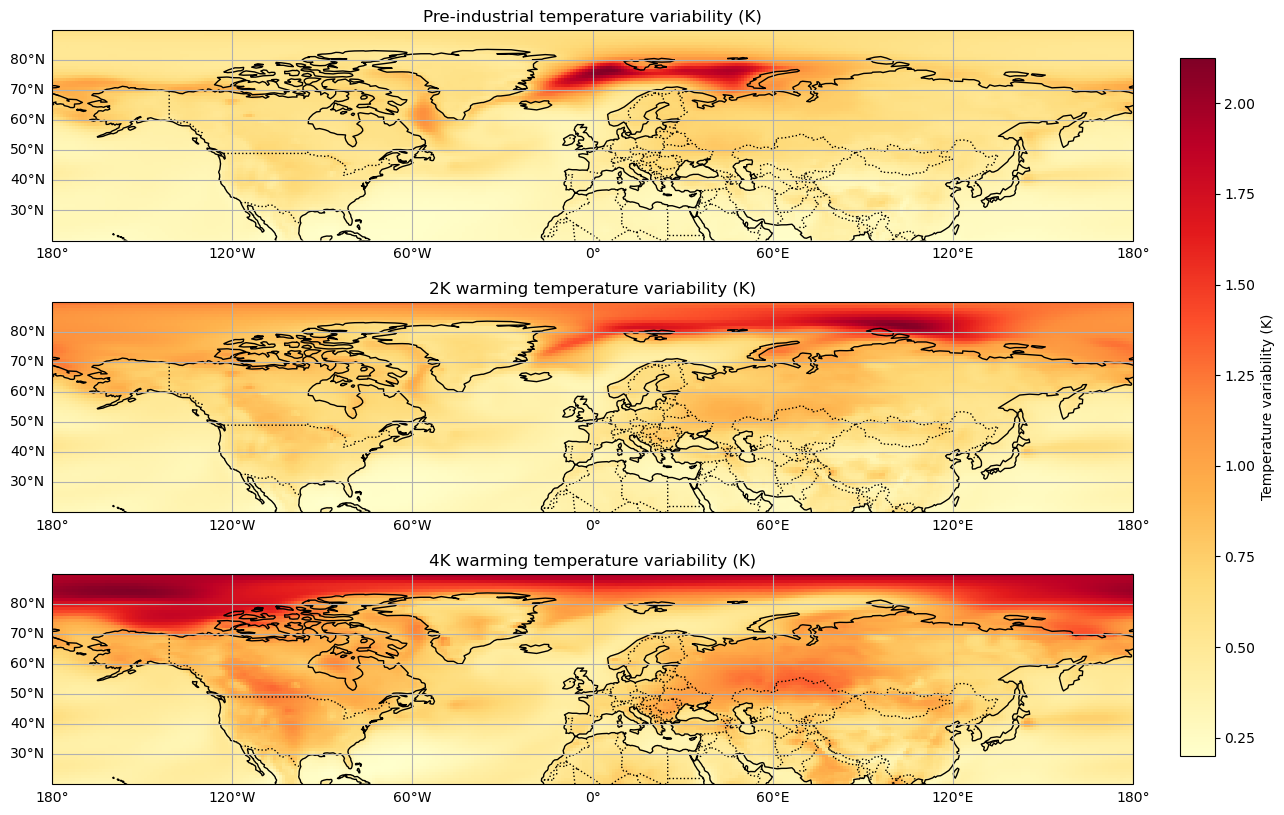

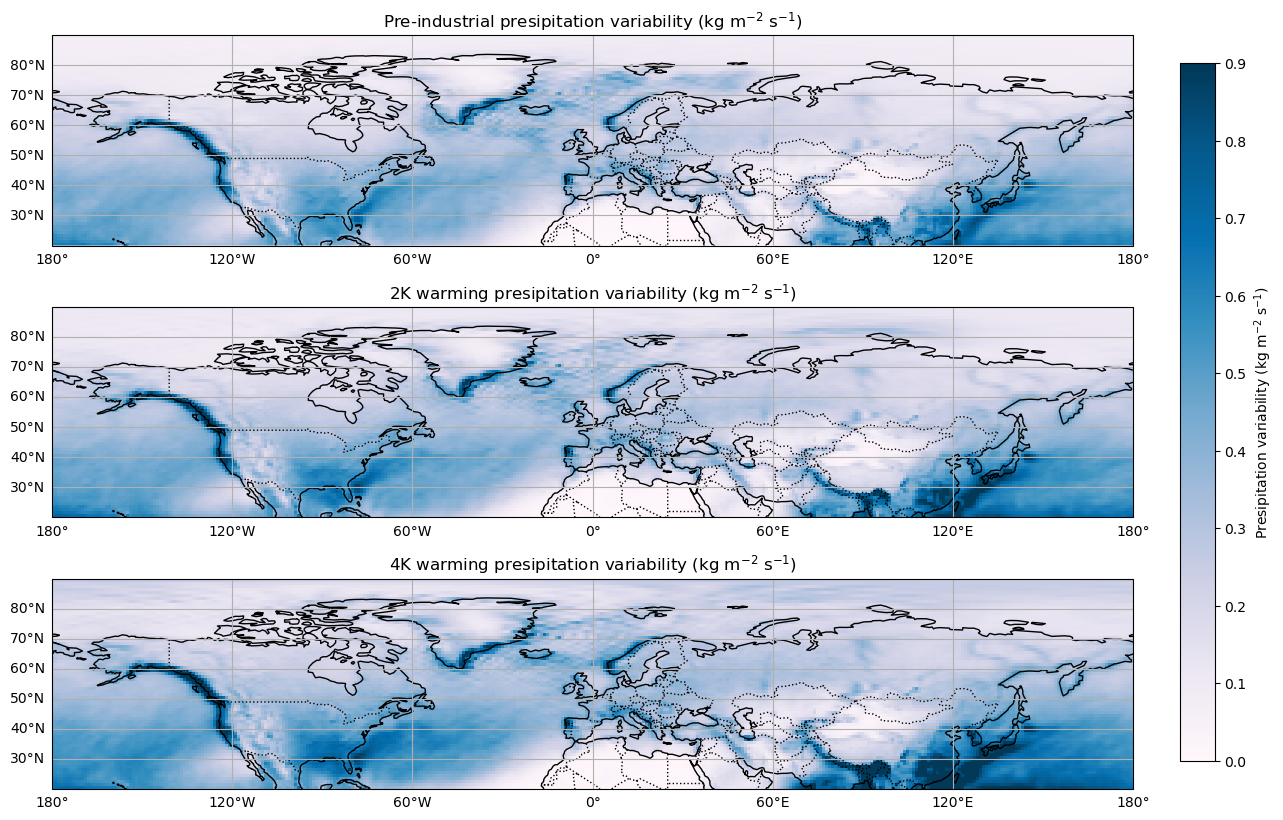

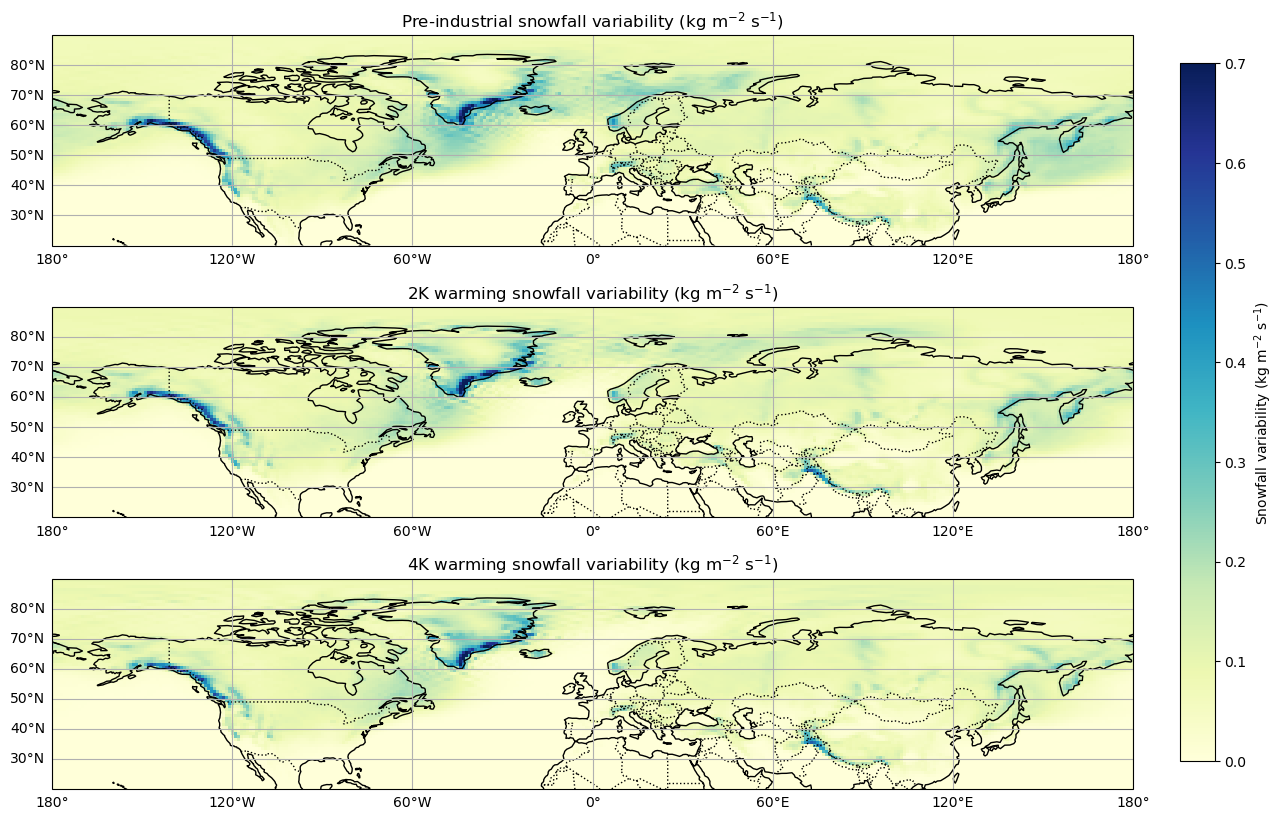

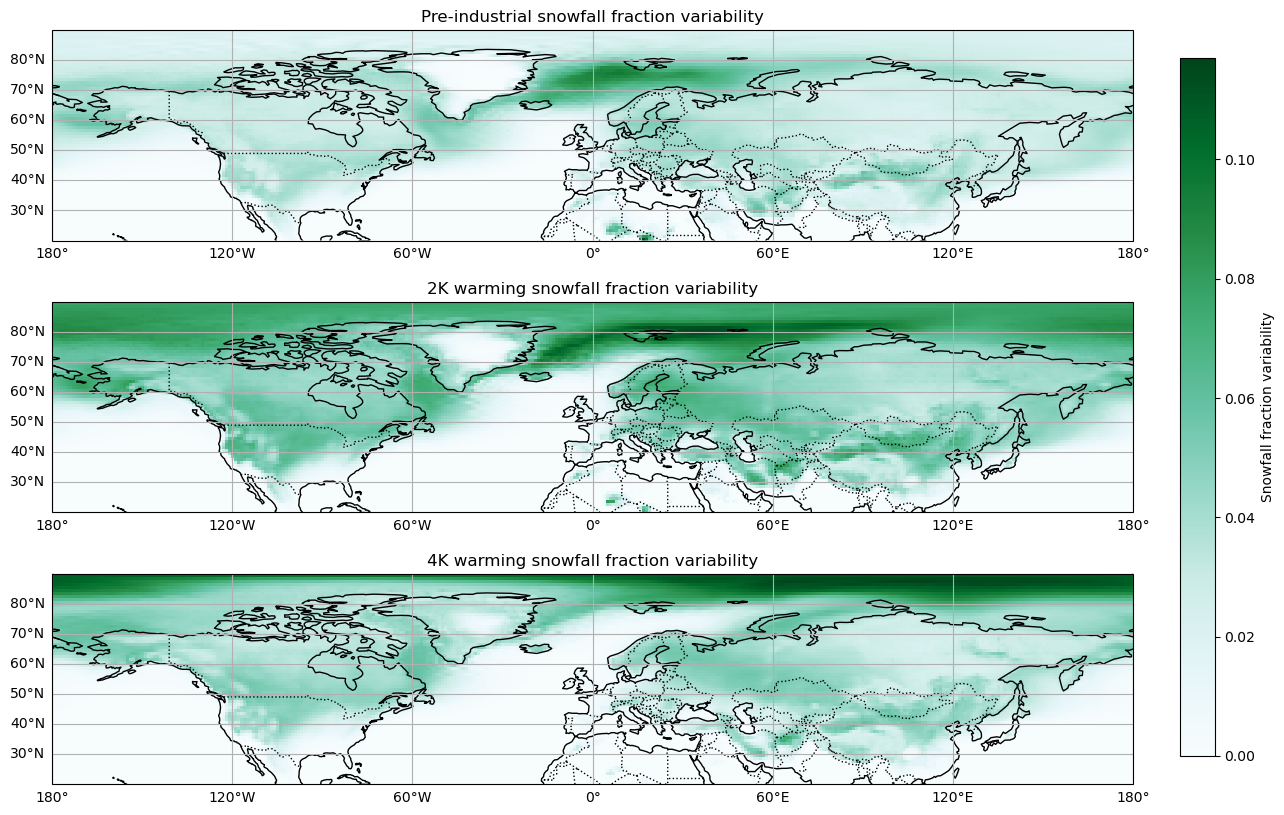

In [336]:
titles = [['Pre-industrial temperature variability (K)', '2K warming temperature variability (K)', '4K warming temperature variability (K)'],
          ['Pre-industrial presipitation variability (kg m$^{-2}$ s$^{-1}$)', '2K warming presipitation variability (kg m$^{-2}$ s$^{-1}$)', '4K warming presipitation variability (kg m$^{-2}$ s$^{-1}$)'],
          ['Pre-industrial snowfall variability (kg m$^{-2}$ s$^{-1}$)', '2K warming snowfall variability (kg m$^{-2}$ s$^{-1}$)', '4K warming snowfall variability (kg m$^{-2}$ s$^{-1}$)'],
          ['Pre-industrial snowfall fraction variability', '2K warming snowfall fraction variability', '4K warming snowfall fraction variability']]

fig, ax = plt.subplots(3, 1, figsize=(15, 10),
                       subplot_kw={"projection": ccrs.PlateCarree()})

# We'll store one of the plot objects for the shared colorbar
mesh = None

for i, variability in enumerate([variability_tas_pi, variability_tas_2K, variability_tas_4K]):
    
    # Plot without creating individual colorbars
    mesh = variability.plot(
        ax=ax[i],
        transform=ccrs.PlateCarree(),
        cmap='YlOrRd',
        add_colorbar=False   # <–– important
    )

    ax[i].set_title(titles[0][i])
    ax[i].coastlines()
    ax[i].add_feature(cfeature.BORDERS, linestyle=':')
    
    gl = ax[i].gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

# ---- Add ONE shared colorbar ----
cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)
cbar.set_label('Temperature variability (K)')

plt.savefig('variability_tas.png')
plt.show()

fig, ax = plt.subplots(3, 1, figsize=(15, 10),
                       subplot_kw={"projection": ccrs.PlateCarree()})

# We'll store one of the plot objects for the shared colorbar
mesh = None


for i, variability in enumerate([variability_pr_pi, variability_pr_2K, variability_pr_4K]):
    
    # Plot without creating individual colorbars
    mesh = variability.plot(
        ax=ax[i],
        transform=ccrs.PlateCarree(),
        vmin=0,
        vmax=0.9,
        cmap='PuBu',
        add_colorbar=False   # <–– important
    )

    ax[i].set_title(titles[1][i])
    ax[i].coastlines()
    ax[i].add_feature(cfeature.BORDERS, linestyle=':')
    
    gl = ax[i].gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

# ---- Add ONE shared colorbar ----
cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)
cbar.set_label('Presipitation variability (kg m$^{-2}$ s$^{-1}$)')

plt.savefig('variability_pr.png')
plt.show()


fig, ax = plt.subplots(3, 1, figsize=(15, 10),
                       subplot_kw={"projection": ccrs.PlateCarree()})

# We'll store one of the plot objects for the shared colorbar
mesh = None

for i, variability in enumerate([variability_prsn_pi, variability_prsn_2K, variability_prsn_4K]):
    
    # Plot without creating individual colorbars
    mesh = variability.plot(
        ax=ax[i],
        transform=ccrs.PlateCarree(),
        vmin=0,
        vmax=0.7,
        cmap='YlGnBu',
        add_colorbar=False   # <–– important
    )

    ax[i].set_title(titles[2][i])
    ax[i].coastlines()
    ax[i].add_feature(cfeature.BORDERS, linestyle=':')
    
    gl = ax[i].gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

# ---- Add ONE shared colorbar ---- 
cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)
cbar.set_label('Snowfall variability (kg m$^{-2}$ s$^{-1}$)')

plt.savefig('variability_prsn.png')
plt.show()

fig, ax = plt.subplots(3, 1, figsize=(15, 10),
                       subplot_kw={"projection": ccrs.PlateCarree()})

# We'll store one of the plot objects for the shared colorbar
mesh = None
for i, variability in enumerate([variability_snfr_pi, variability_snfr_2K, variability_snfr_4K]):
    mesh = variability.plot(
        ax=ax[i],
        transform=ccrs.PlateCarree(),
        cmap='BuGn',
        add_colorbar=False,
        # vmin=0,
        # vmax=0.15
    )

    ax[i].set_title(titles[3][i])
    ax[i].coastlines()
    ax[i].add_feature(cfeature.BORDERS, linestyle=':')
    
    gl = ax[i].gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False


# ---- Add ONE shared colorbar ---- 
cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)
cbar.set_label('Snowfall fraction variability')

plt.savefig('variability_snfr.png')
plt.show()

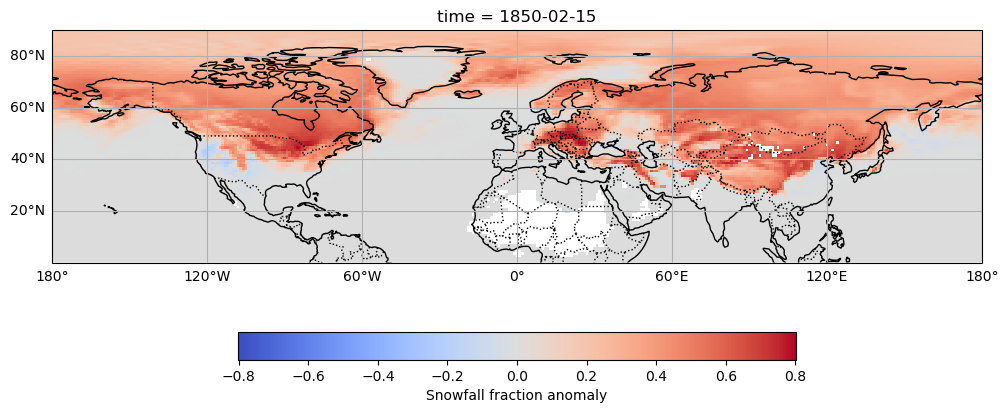

In [328]:
# pr_pi_2d = snfr_2K.sel(time=pd.to_datetime('2057-01-16 12:00:00'))
pr_pi_2d = snfr_2K.isel(time=300)


# Create a figure and axis with a map projection
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# Plot the data
pr_pi_2d['prsn'].plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),  # tells Cartopy that the data is lat/lon
    # vmin=-1.0,
    # vmax=1.0,
    cmap='coolwarm',              # color map
    cbar_kwargs={'label': 'Snowfall fraction anomaly', 'orientation': 'horizontal', 'shrink': 0.6}
)

# Add coastlines and borders
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Add gridlines
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

plt.savefig('snfr_at_time.png')

plt.show()